# Solar Storm Prediction

## Summary
* Sun emits solar wind at the Earth 
* Can create geomagnetic storms affecting power grids, satellites, and communication systems. 
* Useful for operators to receive "early warning" about potential solar storms.
* This project: predict solar storms from incoming solar wind data (~45 minute lead time)

## Problem setup

* Solar storms do not happen all the time -> rare event prediction
* Weather is simply not 100% detectable
* False positive (false alarm) is more desirable than false negative -> prefer to maximize recall subject to fixed precision.
* Weather prediction goals: recall >= .60, precision >= .30

## Data sources
* NASA and NOAA provide data from satellites situated between the Earth and the Sun.
* NASA: historical time-aligned data
* NOAA: realtime solar wind data

## NASA Data
* NASA data is well-documented, but has some eccentricities that require basic cleaning
* Satellite data can have gaps, so data must be appropriately cleaned 
* Input features are hourly, but output response is a rolling 3 hour average

## Feature selection

* Physics informed features: 
  * Angle between solar wind and Earth's magnetic field
  * Energy flux
  * Rolling averages of measurements
  * Variation in magnetic orientation of solar wind
  * "Newell coupling" 
* Some features were highly correlated, so they were dropped to improve model performance
  * Many engineered rolling averages were too highly correlated with raw features.
  * Features encoding solar wind vector had some redundancy and so a few were dropped.

## Model selection
* Time series data
  * Used 20 years of historical data
  * Cross-validation with 1 year folds
* Weather prediction domain
  * Maximize recall with precision >= .30
  * Maintain realistic expectations for results
  * Adjust probability threshold on models
* Hyperparameter tuning using Optuna
* Baselines
  * High precision 0 recall: Dummy classifier always says "No Storm"
  * Other standard models without feature engineering: < 0.3 recall and < 0.6 precision 

## Results
* XGBClassifier gives 0. average recall with 0.3 average precision in cross-validation
* ROC-AUC        : 0.9620
  Avg Precision  : 0.5706
  Brier Score    : 0.0536
  Overall Precision: 0.3260
  Overall Recall : 0.7517

## Limitations and potential
* Will give many false positives
* Further time horizon predictions not realistic without additional data sources
  * Optical data from sun
* Model could be deployed with "online" data from NOAA
  * Data ingestion built, but online deployment not developed for lack of time
* Business use case
  * Provide advanced warning of potential geomagnetic storm to grid operators
 

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.fetch_nasa_omni_historical import load_and_clean_nasa_omni_historical
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

In [2]:
omni_2023 = load_and_clean_nasa_omni_historical(2023, "../data/raw/")
print(f"OMNI 2023 shape: {omni_2023.shape}")
print(f"Date range: {omni_2023.index.min()} to {omni_2023.index.max()}")
print("\nFirst few rows:")
print(omni_2023.head())
print("\nData types:")
print(omni_2023.dtypes)

2026-03-21 22:28:34,135 - INFO - Found existing raw data file for year 2023 at ../data/raw/omni2_2023_raw.csv. Loading...


OMNI 2023 shape: (8760, 10)
Date range: 2023-01-01 00:00:00 to 2023-12-31 23:00:00

First few rows:
                     Year  DOY  Hour  IMF_Mag  Bx_GSE  By_GSE  Bz_GSE  \
Timestamp                                                               
2023-01-01 00:00:00  2023  1.0     0     -1.9     4.6    -0.7     4.6   
2023-01-01 01:00:00  2023  1.0     1     -3.9    -0.6     0.6    -0.7   
2023-01-01 02:00:00  2023  1.0     2     -3.9    -1.2     1.5    -1.5   
2023-01-01 03:00:00  2023  1.0     3     -3.4     1.5     0.4     1.4   
2023-01-01 04:00:00  2023  1.0     4     -2.4     2.7     0.7     2.6   

                     Proton_Density  Plasma_Speed  Kp_index  
Timestamp                                                    
2023-01-01 00:00:00             2.4         603.0        23  
2023-01-01 01:00:00             2.6         582.0        23  
2023-01-01 02:00:00             2.6         581.0        23  
2023-01-01 03:00:00             2.4         576.0        30  
2023-01-01 04:00

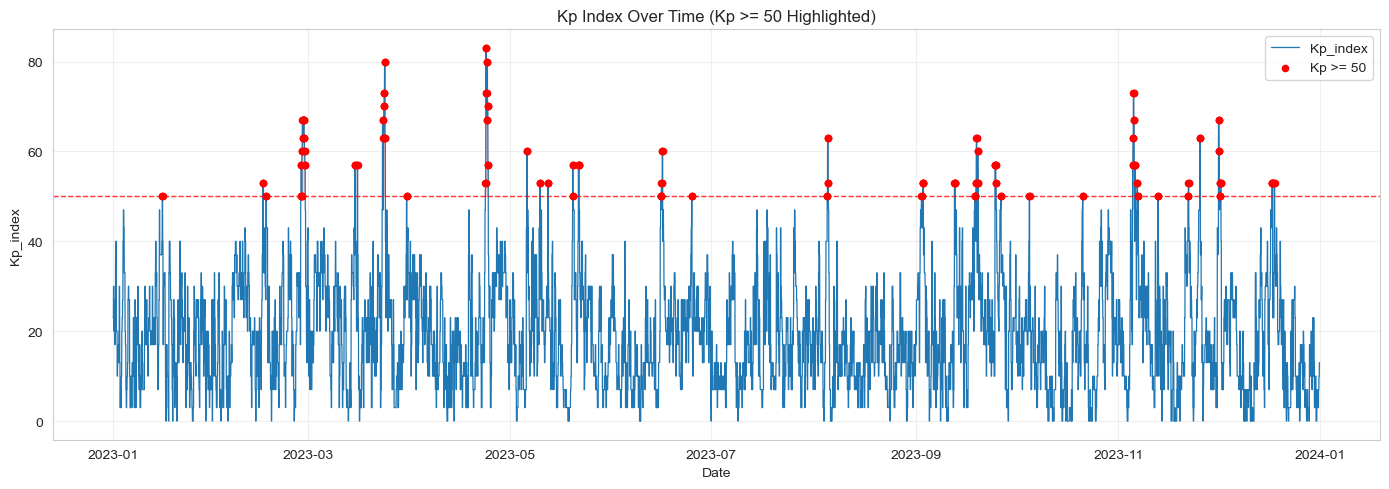

In [3]:

# Kp over time with highlights where Kp >= 50
kp = omni_2023["Kp_index"]
storm_mask = kp >= 50

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(omni_2023.index, kp, color="#1f77b4", linewidth=0.9, label="Kp_index")
ax.scatter(
    omni_2023.index[storm_mask],
    kp[storm_mask],
    color="red",
    s=20,
    label="Kp >= 50",
    zorder=3
)
ax.axhline(50, color="red", linestyle="--", linewidth=1, alpha=0.8)

# Optional shading for threshold exceedance
ax.fill_between(
    omni_2023.index,
    kp,
    50,
    where=storm_mask,
    color="red",
    alpha=0.2,
    interpolate=True
)

ax.set_title("Kp Index Over Time (Kp >= 50 Highlighted)")
ax.set_xlabel("Date")
ax.set_ylabel("Kp_index")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()